# Phase 5: the simulation

Two macro blocks run on identical monthly debt accounting and identical random numbers:

* **VAR block**: the estimated levels VAR (Gaussian shocks), the transparent benchmark (`docs/decisions/0005`).
* **State block**: block factors and the latent chain with bootstrapped residuals (`0007`), the thesis's own construction.

The fiscal premium is added on top of the base 10y from last quarter's debt/GDP and transmitted to the real economy
each block's way. Paths are filtered by feasibility, never clipped (every rejection is reported). The trigger is the
identity-based one from Phase 4; the old threshold is shown only for comparison.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display, Markdown
import bond_sim.notebook as nb
pd.set_option("display.width", 170); pd.set_option("display.max_columns", 40); pd.set_option("display.max_rows", 80)
plt.rcParams["figure.dpi"] = 110

# ── parameters: change and rerun ─────────────────────────────────────────────
AS_OF = pd.Timestamp("2026-09-15")     # every loader filters on this date (point-in-time contract)
K = 1000                                 # Monte Carlo paths (raise for the paper)
FORCE_REFRESH = False                  # True re-downloads every series and rebuilds cached steps
os.environ["BOND_SIM_CACHE"] = "0" if FORCE_REFRESH else "1"
import bond_sim.config as bcfg
CFG_HASH = bcfg.load().content_hash()   # every cached step is keyed by the configuration that produced it
ctx = nb.cached(f"ctx_{AS_OF.date()}_{CFG_HASH}", lambda: nb.load_context(AS_OF), refresh=FORCE_REFRESH)
print(ctx.grid, "| config hash", CFG_HASH, "| series:", ctx.w.shape[1])

MonthlyGrid(1980-01-01 .. 2056-09-01, M=921) | config hash d9222bd624fd | series: 48


In [2]:
from bond_sim.sim import NoPremium, LinearPremium, evaluate_paths
book, auctions, agg, short = nb.cached(f"book_{AS_OF.date()}_{CFG_HASH}", lambda: nb.build_book(ctx), refresh=FORCE_REFRESH)
bf, chain = nb.cached(f"factors_chain_{AS_OF.date()}_{CFG_HASH}", lambda: nb.fit_factors_and_chain(ctx), refresh=FORCE_REFRESH)
var = nb.fit_var(ctx)
init = nb.initial_state(ctx, book, auctions)
H_, feas, h = nb.history_sustainability(ctx, agg)
print({k: (round(v, 2) if isinstance(v, float) else v) for k, v in init.__dict__.items() if not isinstance(v, np.ndarray)})
print(f"VAR({var.lag}) long-run means: {var.long_run_means().round(2).to_dict()}   |   chain: {chain.describe()}")
print("premium:", nb.premium_from_config(ctx.cfg.doomloop.risk_premium).describe(), "  feasible pb envelope:", f"{100*feas.envelope:.2f}%")

{'debt_public_mm': 31828001.46, 'gdp_saar_mm': 32486066.0, 'r10_pct': 4.83, 'r3m_pct': 3.95, 'u_pct': 4.1, 'pb_pct_gdp': -2.71, 'g_nom_pct': 6.57, 'avg_new_maturity_months': 72.04, 'bill_share': 0.2, 'receipts_gdp_pct': 16.59}
VAR(3) long-run means: {'r10': 4.04, 'r3m': 3.05, 'g_nom': 5.5, 'pb': -3.24, 'u': 5.03}   |   chain: 2-state latent chain on 7 block factors (hazard beta 0.00)
premium: linear: 2.0 bps per pt of debt/GDP above 100.0%   feasible pb envelope: 2.15%


## 5.1 Status quo under both blocks

In [3]:
runs = {}
for name in ("VAR", "states"):
    factory = (lambda shocks, n=name: nb.make_blocks(ctx, var, bf, chain, shocks)[n])
    runs[name] = nb.run_scenarios(ctx, init, feas, factory, ["status_quo"], K)[("none", "status_quo")]
summ = pd.DataFrame({n: r.summary() for n, r in runs.items()}).T
display(summ[["block", "admissible_share", "P(trigger)", "P(trigger_threshold)", "median_years_to_trigger", "median_end_debt_gdp", "median_end_r10", "median_end_u", "median_end_g_nom", "median_end_pb", "median_end_interest_12m_gdp"]].round(3))
display(pd.DataFrame({n: r.rejections for n, r in runs.items()}))

,block,admissible_share,P(trigger),P(trigger_threshold),median_years_to_trigger,median_end_debt_gdp,median_end_r10,median_end_u,median_end_g_nom,median_end_pb,median_end_interest_12m_gdp
VAR,"levels VAR(3), Gaussian shocks",1.0,0.603,0.924,16.916667,148.270874,5.050001,5.015103,5.297473,-2.841532,6.273682
states,2-state latent chain on 7 block factors (hazar...,0.996,0.583333,0.503012,14.166667,121.226491,4.21555,5.114955,4.95076,-1.996087,4.159869


,VAR,states
nonfinite,0,0
gdp_nonpositive,0,0
u_outside_1_35,0,3
yield_outside_0_30,0,0
infl_outside_-15_50,0,0
growth_outside_-30_40,0,1
debt_negative,0,0


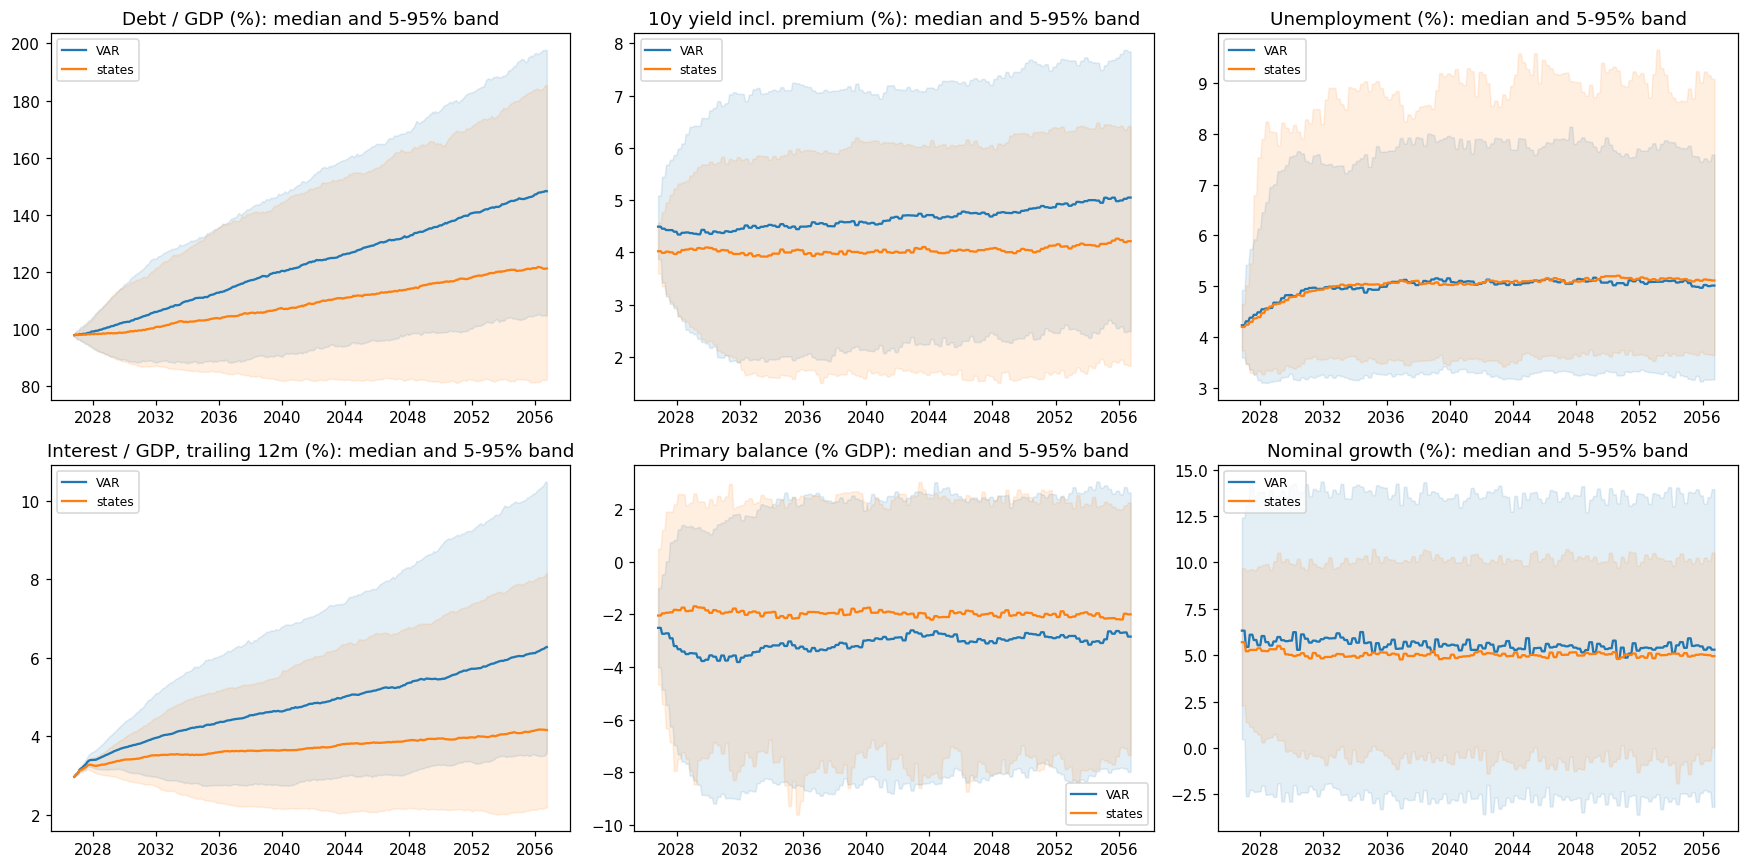

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, v, title in zip(axes.ravel(), ("debt_gdp", "r10", "u", "interest_12m_gdp", "pb", "g_nom"),
                        ("Debt / GDP (%)", "10y yield incl. premium (%)", "Unemployment (%)", "Interest / GDP, trailing 12m (%)", "Primary balance (% GDP)", "Nominal growth (%)")):
    for n, r in runs.items():
        nb.fan(ax, r, v, n)
    ax.set_title(f"{title}: median and 5-95% band"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 5.2 The trigger: probability, timing, and what growth would be needed

`P(trigger)` is the share of admissible paths on which the debt-stabilizing primary balance exceeds the feasible one for
12 consecutive months. The threshold version (150% debt/GDP or 30% interest/receipts) is a different, cruder question.

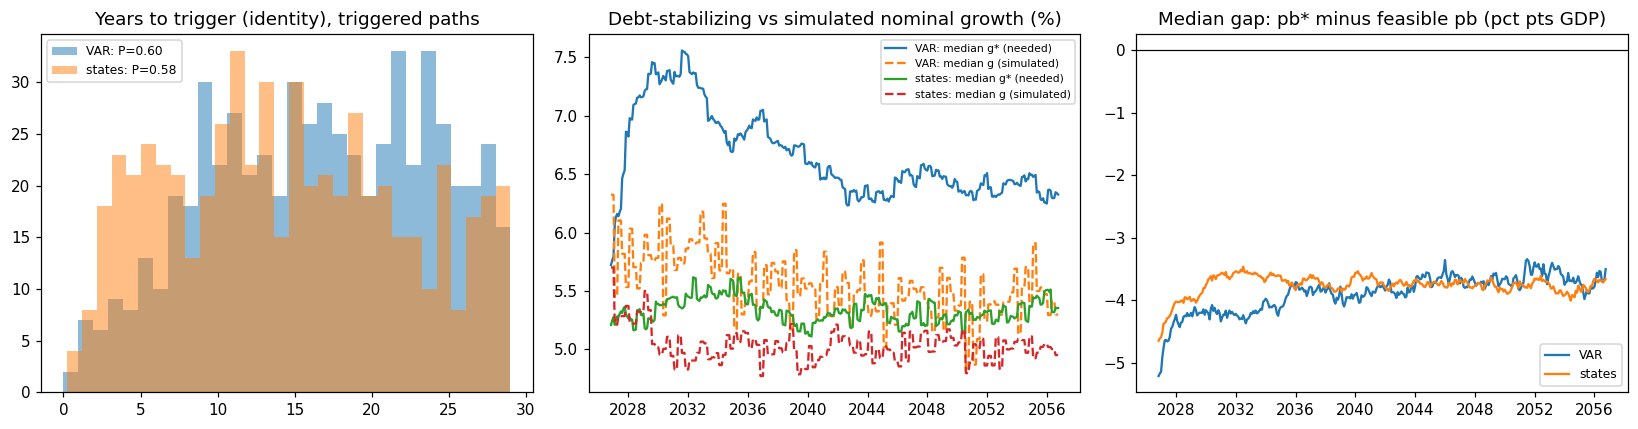

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for n, r in runs.items():
    ttt = r.time_to_trigger_years()
    ax[0].hist(ttt, bins=30, alpha=0.5, label=f"{n}: P={r.trigger_probability():.2f}")
    gs = r.sustainability
    ax[1].plot(r.dates, 100 * np.nanmedian(gs.g_star[r.admissible], axis=0), label=f"{n}: median g* (needed)")
    ax[1].plot(r.dates, np.nanmedian(r.paths["g_nom"][r.admissible], axis=0), ls="--", label=f"{n}: median g (simulated)")
    ax[2].plot(r.dates, 100 * np.nanmedian(gs.gap[r.admissible], axis=0), label=n)
ax[0].set_title("Years to trigger (identity), triggered paths"); ax[0].legend(fontsize=8)
ax[1].set_title("Debt-stabilizing vs simulated nominal growth (%)"); ax[1].legend(fontsize=7)
ax[2].axhline(0, color="k", lw=0.8); ax[2].set_title("Median gap: pb* minus feasible pb (pct pts GDP)"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 5.3 Shape of the outcome distribution

The state block exists to produce the tails history has. Terminal debt/GDP: skewness and excess kurtosis under each
block (a normal has zero of both), plus state occupancy over the horizon.

,VAR,states
median,148.27,121.23
mean,148.86,126.19
std,28.87,32.12
skew,0.17,0.87
excess_kurtosis,0.02,1.25
p05,104.93,82.39
p95,197.69,185.43


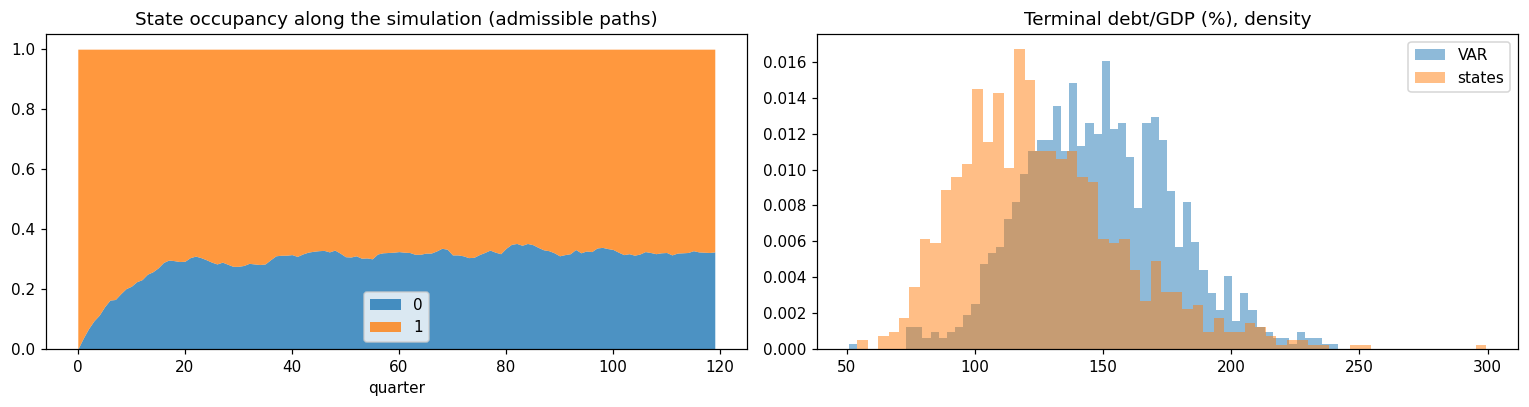

In [6]:
display(pd.DataFrame({n: nb.shape_stats(r, "debt_gdp") for n, r in runs.items()}).round(2))
r = runs["states"]
occ = chain.occupancy(r.paths["state"][r.admissible][:, 2::3].astype(int))
fig, ax = plt.subplots(1, 2, figsize=(14, 3.8))
occ.plot.area(ax=ax[0], linewidth=0, alpha=0.8); ax[0].set_title("State occupancy along the simulation (admissible paths)"); ax[0].set_xlabel("quarter")
for n, rr in runs.items():
    x = rr.paths["debt_gdp"][rr.admissible, -1]; ax[1].hist(x[np.isfinite(x)], bins=60, alpha=0.5, density=True, label=n)
ax[1].set_title("Terminal debt/GDP (%), density"); ax[1].legend(); plt.tight_layout(); plt.show()

## 5.4 The two placeholders the state block's loop rests on

The state block's doom loop runs through P-01 (premium slope, bps of 10y per point of debt/GDP) and P-16 (how much a
point of premium tightens financial conditions, default: like a point of Baa spread). Neither is estimated here. The
grid below reruns the status quo on the same draws across both, so the reader sees how much of the probability is the
mechanism and how much is the placeholder. The VAR block only depends on P-01.

In [7]:
from bond_sim.sim import LinearPremium, StateBlock
rows = []
HQ = (len(init.legacy_interest_mm) + 2) // 3
draws_s = StateBlock(bf, chain).prepare(K, HQ, np.random.default_rng(ctx.cfg.sim.seed))
k_default = StateBlock(bf, chain).k_prem
for slope in (0.0, 1.0, 2.0, 5.0):
    for scale in (0.0, 0.25, 0.5, 1.0):
        blk = StateBlock(bf, chain, premium_to_financial=k_default * scale)
        r = nb.DoomLoopSimulator(ctx.cfg, blk, LinearPremium(slope, ctx.cfg.doomloop.risk_premium.anchor_debt_gdp_pct), init,
                                 nb.policy_from_name("status_quo", ctx.cfg.policy), feasible=feas).run(K=K, draws=draws_s, start=AS_OF + pd.DateOffset(months=1))
        ok = r.admissible
        rows.append({"premium bps/pt (P-01)": slope, "premium->conditions x default (P-16)": scale, "admissible": float(ok.mean()),
                     "P(trigger)": r.trigger_probability(), "median_end_debt_gdp": float(np.median(r.paths["debt_gdp"][ok, -1])),
                     "share_in_stress_state_2056": float((r.paths["state"][ok, -1] == 0).mean())})
grid = pd.DataFrame(rows)
display(grid.pivot(index="premium bps/pt (P-01)", columns="premium->conditions x default (P-16)", values="P(trigger)").round(3))
display(grid.pivot(index="premium bps/pt (P-01)", columns="premium->conditions x default (P-16)", values="share_in_stress_state_2056").round(3))
print(f"default premium->conditions mapping: {k_default:.2f} financial-factor sd per pct point of premium")

premium->conditions x default (P-16),0.00,0.25,0.50,1.00
premium bps/pt (P-01),,,,
0.0,0.527,0.527,0.527,0.527
1.0,0.547,0.550,0.555,0.559
2.0,0.565,0.573,0.577,0.583
5.0,0.635,0.648,0.667,0.683


premium->conditions x default (P-16),0.00,0.25,0.50,1.00
premium bps/pt (P-01),,,,
0.0,0.324,0.324,0.324,0.324
1.0,0.324,0.324,0.324,0.324
2.0,0.324,0.324,0.324,0.324
5.0,0.324,0.324,0.325,0.325


default premium->conditions mapping: -1.21 financial-factor sd per pct point of premium


## 5.5 Sensitivity of the trigger to its own free numbers

Persistence N, the feasible benchmark, and the r > g requirement, re-evaluated on the same simulated paths (no
re-simulation needed).

In [8]:
rows = []
for n, r in runs.items():
    ok = r.admissible
    for which in ("envelope", "reaction"):
        for require in (True, False):
            for months in (6, 12, 24):
                diag = evaluate_paths(r.paths["debt_gdp"][ok] / 100, r.paths["r_eff"][ok] / 100, r.paths["g_nom"][ok] / 100, r.paths["pb"][ok] / 100,
                                      feas, months, which=which, u=r.paths["u"][ok], require_r_gt_g=require)
                rows.append({"block": n, "benchmark": which, "require r>g": require, "persistence_months": months, "P(trigger)": diag.probability(), **diag.lead_indicator_test()})
display(pd.DataFrame(rows).round(3))

,block,benchmark,require r>g,persistence_months,P(trigger),delta2_d_positive_share_pre_trigger,delta3_d_positive_share_pre_trigger
0,VAR,envelope,True,6,0.888,0.537,0.373
1,VAR,envelope,True,12,0.603,0.529,0.358
2,VAR,envelope,True,24,0.114,0.530,0.353
3,VAR,envelope,False,6,0.888,0.537,0.373
4,VAR,envelope,False,12,0.603,0.529,0.358
5,VAR,envelope,False,24,0.114,0.530,0.353
6,VAR,reaction,True,6,0.999,0.523,0.406
7,VAR,reaction,True,12,0.973,0.523,0.388
8,VAR,reaction,True,24,0.567,0.517,0.361
9,VAR,reaction,False,6,1.000,NaN,NaN
